In [ ]:
# Machine Learning Lab Notebook: Importing and Classifying Data for Training a Custom BERT model

This notebook walks students through a complete text classification workflow:

1. Load data from a CSV file  
2. Inspect and clean the dataset  
3. Define labels and features  
4. Train a simple baseline classifier  
5. Fine-tune a BERT classifier with PyTorch  
6. Evaluate the model with common metrics  

Use the included sample CSV file:

`student_tickets_sample.csv`

## Learning goals

By the end of this lab, students should be able to:

- explain the difference between features and labels
- load CSV data into a pandas DataFrame
- prepare text for machine learning
- train a baseline classifier
- fine-tune a BERT model with PyTorch
- interpret accuracy, precision, recall, and F1-score

In [ ]:
# Install packages if needed
# Uncomment this cell if you are running in a fresh environment

# !pip install pandas scikit-learn torch transformers matplotlib

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## Step 1: Load the CSV file

In [3]:
csv_path = "student_tickets_sample.csv"
df = pd.read_csv(csv_path)

print(df.head())
print()
print(df.info())
print()
print(df['label'].value_counts())

                                   text      label
0              Reset my password please    support
1            I want to buy a new laptop      sales
2              My order arrived damaged  complaint
3  Can you tell me your business hours?    general
4   I need help logging into my account    support

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    24 non-null     str  
 1   label   24 non-null     str  
dtypes: str(2)
memory usage: 516.0 bytes
None

label
support      6
sales        6
complaint    6
general      6
Name: count, dtype: int64


### Questions

- How many rows are in the dataset?
- How many unique labels are there?
- Is the class distribution balanced?
- Are there any missing values?

## Step 2: Clean and prepare the data

In [4]:
data = df[['text', 'label']].dropna().copy()
data['text'] = data['text'].astype(str).str.strip()
data['label'] = data['label'].astype(str).str.strip()

print(data.head())

                                   text      label
0              Reset my password please    support
1            I want to buy a new laptop      sales
2              My order arrived damaged  complaint
3  Can you tell me your business hours?    general
4   I need help logging into my account    support


## Step 3: Encode labels

Machine learning models work with numbers, so we convert string labels into integer IDs.

In [5]:
label_encoder = LabelEncoder()
data['label_id'] = label_encoder.fit_transform(data['label'])

label_map = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Label mapping:")
print(label_map)

Label mapping:
{'complaint': 0, 'general': 1, 'sales': 2, 'support': 3}


## Step 4: Split the dataset

In [6]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    data['text'].tolist(),
    data['label_id'].tolist(),
    test_size=0.25,
    random_state=42,
    stratify=data['label_id']
)

print(f"Training samples: {len(train_texts)}")
print(f"Test samples: {len(test_texts)}")

Training samples: 18
Test samples: 6


## Step 5: Train a baseline classifier

We start with a simple and fast model: TF-IDF plus Logistic Regression.

This gives us a baseline to compare against BERT.

In [7]:
baseline_model = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000))
])

baseline_model.fit(train_texts, train_labels)
baseline_preds = baseline_model.predict(test_texts)

print(classification_report(test_labels, baseline_preds, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

   complaint       1.00      1.00      1.00         2
     general       0.50      1.00      0.67         1
       sales       1.00      0.50      0.67         2
     support       1.00      1.00      1.00         1

    accuracy                           0.83         6
   macro avg       0.88      0.88      0.83         6
weighted avg       0.92      0.83      0.83         6



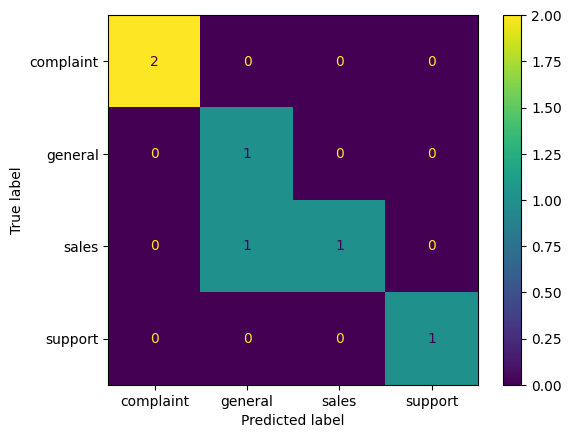

In [8]:
cm = confusion_matrix(test_labels, baseline_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.show()

## Why use a baseline first?

A baseline model is useful because:

- it is fast to train
- it helps us find data problems early
- it gives us a reference point before using a larger deep learning model

## Step 6: Import PyTorch and Transformers for BERT

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader

# Use the modern import path for AdamW
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

## Step 7: Load the tokenizer

In [10]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
tokenizer

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

## Step 8: Build a custom Dataset class

In [11]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

## Step 9: Create DataLoaders

In [12]:
train_dataset = TextDataset(train_texts, train_labels, tokenizer, max_len=64)
test_dataset = TextDataset(test_texts, test_labels, tokenizer, max_len=64)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

len(train_dataset), len(test_dataset)

(18, 6)

## Step 10: Load the BERT classifier

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(label_encoder.classes_)
)
model.to(device)

Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

## Step 11: Define optimizer

In [24]:
optimizer = AdamW(model.parameters(), lr=2e-5)

## Step 12: Train the BERT model

This example uses a small number of epochs for classroom speed.

In [25]:
num_epochs = 2
training_losses = []

model.train()

for epoch in range(num_epochs):
    total_loss = 0.0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_loader)
    training_losses.append(avg_loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {avg_loss:.4f}")

Epoch 1/2 - Loss: 1.3902
Epoch 2/2 - Loss: 1.2983


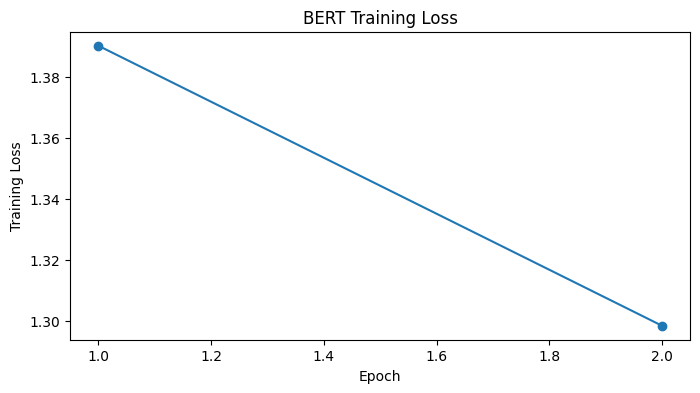

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(training_losses) + 1), training_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("BERT Training Loss")
plt.show()

## Step 13: Evaluate BERT

In [31]:
model.eval()

all_preds = []
all_true = []

# we use torch.no_grad() for a context manager setting that disables a backward pass graph for performance
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_true, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_true, all_preds, average='weighted', zero_division=0
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print()
print(classification_report(all_true, all_preds, target_names=label_encoder.classes_, zero_division=0))

Accuracy:  0.6667
Precision: 0.4722
Recall:    0.6667
F1-score:  0.5444

              precision    recall  f1-score   support

   complaint       0.67      1.00      0.80         2
     general       0.50      1.00      0.67         1
       sales       0.00      0.00      0.00         2
     support       1.00      1.00      1.00         1

    accuracy                           0.67         6
   macro avg       0.54      0.75      0.62         6
weighted avg       0.47      0.67      0.54         6



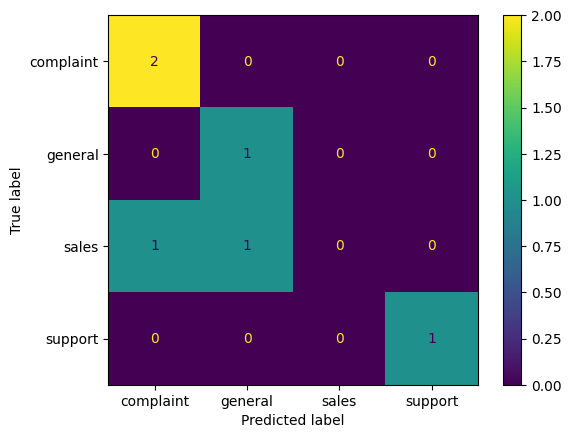

In [32]:
cm = confusion_matrix(all_true, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.show()

## Step 14: Try inference on new text

In [38]:
sample_texts = [
    "My account password no longer works",
    "Can you send me pricing for 100 licenses?",
    "The package arrived broken and incomplete",
    "What time do you close tonight?"
]

model.eval()

for text in sample_texts:
    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=64,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    # we use torch.no_grad() for a context manager setting that disables a backward pass graph for performance
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        pred_id = torch.argmax(outputs.logits, dim=1).item()

    pred_label = label_encoder.inverse_transform([pred_id])[0]
    print(f"Text: {text}")
    print(f"Predicted label: {pred_label}")
    print("-" * 60)

Text: My account password no longer works
Predicted label: support
------------------------------------------------------------
Text: Can you send me pricing for 100 licenses?
Predicted label: support
------------------------------------------------------------
Text: The package arrived broken and incomplete
Predicted label: complaint
------------------------------------------------------------
Text: What time do you close tonight?
Predicted label: general
------------------------------------------------------------


## Extension ideas

- add a validation split
- try DistilBERT instead of BERT
- increase the dataset size
- handle imbalanced classes
- save and reload the trained model
- build a small web app for inference

## Instructor note

This sample dataset is intentionally tiny so students can understand the pipeline quickly.

BERT will run, but results on such a small dataset are not meaningful for real production use. That is normal and is part of the teaching point. Students should learn both the workflow and the limits of small datasets.